# Practical 6: Object Recognition using Transfer Learning of CNN Architectures

**Aim:** Reuse a CNN pre-trained on a large dataset (ImageNet, 1.2 million images, 1000 classes) and adapt it to a new task: classifying CIFAR-10 images.

**Pre-trained model:** MobileNetV2 (ImageNet weights, stored locally in `models/`).
**Dataset:** CIFAR-10 (`datasets/cifar10.npz`). To keep training fast on lab CPUs we use a subset (10,000 train / 2,000 test images). Increase `N_TRAIN` if time allows.

**Note on "object detection":** the syllabus steps below describe transfer learning for recognising which object is in an image (classification). Full object detection (drawing boxes) uses the same idea: a pre-trained CNN such as MobileNetV2 is used as the "backbone" feature extractor, and a detection head is trained on top.

**Steps (as per syllabus):**
- a. Load in a pre-trained CNN model trained on a large dataset
- b. Freeze parameters (weights) in the model's lower convolutional layers
- c. Add a custom classifier with several layers of trainable parameters to the model
- d. Train the classifier layers on the training data available for the task
- e. Fine-tune hyperparameters and unfreeze more layers as needed

In [2]:
# ---------------------------------------------------------------
# Common setup: imports, reproducibility, and offline data folder
# ---------------------------------------------------------------
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TensorFlow INFO/WARNING logs so outputs stay readable

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

# Fix the random seeds (Python, NumPy, TensorFlow) so every run gives similar numbers.
# This makes it easy to compare results between students.
keras.utils.set_random_seed(42)

# All data is read from the local "datasets" folder that sits next to this notebook.
# Nothing is downloaded from the internet.
DATA_DIR = Path("datasets")
MODEL_DIR = Path("models")
assert DATA_DIR.exists(), "datasets folder not found - "

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
WEIGHTS_FILE = MODEL_DIR / "mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5"
assert WEIGHTS_FILE.exists(), "Pre-trained weights missing: run prepare_offline.py on an internet machine first"

### Load and inspect the task data (CIFAR-10 subset)

train: (10000, 32, 32, 3) test: (2000, 32, 32, 3)
images per class in the subset: [1005  974 1032 1016  999  937 1030 1001 1025  981]


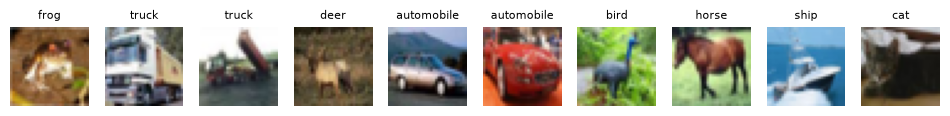

In [5]:
N_TRAIN, N_TEST = 10000, 2000
IMG_SIZE = 96          # MobileNetV2 ImageNet weights exist for 96, 128, 160, 192, 224 pixel inputs

data = np.load(DATA_DIR / "cifar10.npz")
x_train, y_train = data["x_train"][:N_TRAIN], data["y_train"].reshape(-1)[:N_TRAIN]
x_test,  y_test  = data["x_test"][:N_TEST],   data["y_test"].reshape(-1)[:N_TEST]

print("train:", x_train.shape, "test:", x_test.shape)
print("images per class in the subset:", np.bincount(y_train))

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1); plt.imshow(x_train[i]); plt.title(CLASS_NAMES[y_train[i]], fontsize=8); plt.axis("off")
plt.show()

## Step a: Load a pre-trained CNN model trained on a large dataset

- `include_top=False` removes MobileNetV2's original 1000-class ImageNet classifier. We keep only the convolutional part, which turns an image into a set of features.
- `weights=` points to the locally stored ImageNet weights, so nothing is downloaded.

In [6]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights=str(WEIGHTS_FILE),
)

print("Number of layers in MobileNetV2:", len(base_model.layers))
print("Total parameters               :", f"{base_model.count_params():,}")
print("Input shape                    :", base_model.input_shape)
print("Output shape                   :", base_model.output_shape, "-> a 3x3 grid of 1280 features")
print("\nFirst 5 layers:", [l.name for l in base_model.layers[:5]])
print("Last 5 layers :", [l.name for l in base_model.layers[-5:]])

Number of layers in MobileNetV2: 154
Total parameters               : 2,257,984
Input shape                    : (None, 96, 96, 3)
Output shape                   : (None, 3, 3, 1280) -> a 3x3 grid of 1280 features

First 5 layers: ['input_layer', 'Conv1', 'bn_Conv1', 'Conv1_relu', 'expanded_conv_depthwise']
Last 5 layers : ['block_16_project', 'block_16_project_BN', 'Conv_1', 'Conv_1_bn', 'out_relu']


In [7]:
# Inspect: what does the pre-trained network produce for one CIFAR image?
# Steps: resize 32x32 -> 96x96, then scale pixels to [-1, 1] as MobileNetV2 expects.
one = keras.ops.image.resize(x_train[:1].astype("float32"), (IMG_SIZE, IMG_SIZE))
one = keras.applications.mobilenet_v2.preprocess_input(one)
print("preprocessed pixel range:", float(keras.ops.min(one)), "to", float(keras.ops.max(one)))

features = base_model(one, training=False)
print("feature tensor shape:", tuple(features.shape))
print("first 10 of 1280 averaged features:", np.round(keras.ops.convert_to_numpy(keras.ops.mean(features, axis=(1, 2)))[0][:10], 3))

preprocessed pixel range: -1.0 to 1.0
feature tensor shape: (1, 3, 3, 1280)
first 10 of 1280 averaged features: [0.694 0.    0.    0.    3.305 0.    0.721 1.076 0.934 1.618]


## Step b: Freeze the parameters of the pre-trained convolutional layers

`base_model.trainable = False` freezes all its weights. During training, gradients will only update our new classifier layers.
The lower layers already know general visual features (edges, textures, shapes) from ImageNet, and our small dataset would only damage them at this stage.

In [9]:
base_model.trainable = False

def count_params(model):
    trainable = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
    frozen = sum(int(np.prod(w.shape)) for w in model.non_trainable_weights)
    return trainable, frozen

t, f = count_params(base_model)
print(f"base model -> trainable: {t:,} | frozen: {f:,}")
print("trainable flags of first 5 layers:", [l.trainable for l in base_model.layers[:5]])

base model -> trainable: 0 | frozen: 2,257,984
trainable flags of first 5 layers: [False, False, False, False, False]


## Step c: Add a custom classifier with several trainable layers

```
Input 32x32x3
 -> Resizing to 96x96                (MobileNetV2 weights need at least 96x96)
 -> Rescaling to [-1, 1]              (the preprocessing MobileNetV2 was trained with)
 -> MobileNetV2 base (frozen)         output 3x3x1280
 -> GlobalAveragePooling2D            1280 numbers
 -> Dense(256, ReLU) -> Dropout(0.3)
 -> Dense(128, ReLU) -> Dropout(0.3)
 -> Dense(10, Softmax)                new classifier for the 10 CIFAR-10 classes
```

`base_model(x, training=False)` keeps the BatchNormalization layers of the base in inference mode, which is important later when we unfreeze and fine-tune.

In [10]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE, name="resize")(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="scale_to_minus1_1")(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dense(256, activation="relu", name="fc1")(x)
x = layers.Dropout(0.3, name="drop1")(x)
x = layers.Dense(128, activation="relu", name="fc2")(x)
x = layers.Dropout(0.3, name="drop2")(x)
outputs = layers.Dense(10, activation="softmax", name="classifier")(x)

model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
model.summary()

t, f = count_params(model)
print(f"\nWhole model -> trainable: {t:,} | frozen: {f:,}")
print("Only the new classifier head will be trained in Step d.")

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Resizing)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scale_to_minus1_1 (Rescaling)   │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,106 (9.99 MB)

 Trainable params: 362,122 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Whole model -> trainable: 362,122 | frozen: 2,257,984
Only the new classifier head will be trained in Step d.


## Step d: Train the classifier layers on the task data

Only the new head (about 0.36 million weights) learns. A normal learning rate (0.001) is fine because the head starts from random weights.

In [11]:
x_train_f = x_train.astype("float32")   # scaling happens inside the model
x_test_f = x_test.astype("float32")

HEAD_EPOCHS = 5
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_head = model.fit(x_train_f, y_train, validation_split=0.1,
                         epochs=HEAD_EPOCHS, batch_size=64, verbose=1)

loss_head, acc_head = model.evaluate(x_test_f, y_test, verbose=0)
print(f"\nTest accuracy after training only the head: {acc_head:.4f}")

Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.6661 - loss: 0.9996 - val_accuracy: 0.8240 - val_loss: 0.5450
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.8031 - loss: 0.5872 - val_accuracy: 0.8380 - val_loss: 0.5103
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.8428 - loss: 0.4655 - val_accuracy: 0.8490 - val_loss: 0.4774
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.8640 - loss: 0.4035 - val_accuracy: 0.8460 - val_loss: 0.4695
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - accuracy: 0.8866 - loss: 0.3381 - val_accuracy: 0.8450 - val_loss: 0.5144

Test accuracy after training only the head: 0.8370


## Step e: Fine-tune, unfreeze more layers as needed

Now we unfreeze the **top** part of MobileNetV2 (the last ~50 layers, which hold task-specific, high-level features) and keep the lower layers frozen.

Two rules for fine-tuning:
1. Use a **very small learning rate** (1e-5). Large updates would destroy the useful pre-trained weights.
2. Keep **BatchNormalization** layers frozen (inference mode). Their stored statistics come from ImageNet, and updating them with small batches makes training unstable.

We must **compile again** after changing `trainable`, otherwise the change has no effect.

In [12]:
FINE_TUNE_FROM = 100      # layers before this index stay frozen (MobileNetV2 has about 154 layers)

base_model.trainable = True
for i, layer in enumerate(base_model.layers):
    if i < FINE_TUNE_FROM or isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

n_unfrozen = sum(l.trainable for l in base_model.layers)
print(f"Unfrozen layers in base model: {n_unfrozen} of {len(base_model.layers)}")
print("Examples of unfrozen layers:", [l.name for l in base_model.layers if l.trainable][:6])

t, f = count_params(model)
print(f"Whole model -> trainable: {t:,} | frozen: {f:,}")

Unfrozen layers in base model: 36 of 154
Examples of unfrozen layers: ['block_11_expand_relu', 'block_11_depthwise', 'block_11_depthwise_relu', 'block_11_project', 'block_11_add', 'block_12_expand']
Whole model -> trainable: 2,201,738 | frozen: 418,368


In [13]:
FINE_EPOCHS = 3
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # 100x smaller than before
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_fine = model.fit(x_train_f, y_train, validation_split=0.1,
                         epochs=FINE_EPOCHS, batch_size=64, verbose=1)

loss_fine, acc_fine = model.evaluate(x_test_f, y_test, verbose=0)
print(f"\nTest accuracy: head only = {acc_head:.4f} | after fine-tuning = {acc_fine:.4f}")

Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.9097 - loss: 0.2666 - val_accuracy: 0.8600 - val_loss: 0.4440
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9282 - loss: 0.2151 - val_accuracy: 0.8760 - val_loss: 0.4439
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.9390 - loss: 0.1809 - val_accuracy: 0.8690 - val_loss: 0.4410

Test accuracy: head only = 0.8370 | after fine-tuning = 0.8610


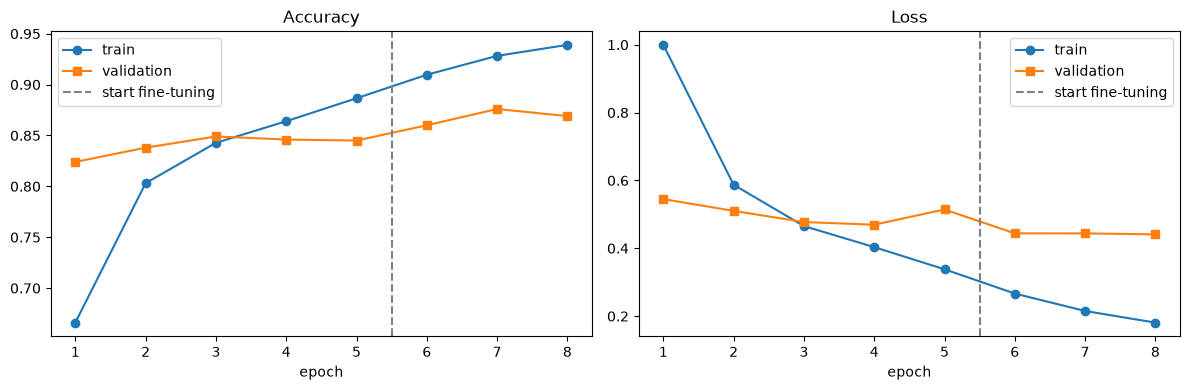

In [14]:
# Combined training curves; the dashed line marks where fine-tuning starts
acc = history_head.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history_head.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history_head.history["loss"] + history_fine.history["loss"]
val_loss = history_head.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 4))
for k, (tr, va, name) in enumerate([(acc, val_acc, "Accuracy"), (loss, val_loss, "Loss")]):
    plt.subplot(1, 2, k + 1)
    plt.plot(range(1, len(tr) + 1), tr, "o-", label="train")
    plt.plot(range(1, len(va) + 1), va, "s-", label="validation")
    plt.axvline(HEAD_EPOCHS + 0.5, color="gray", linestyle="--", label="start fine-tuning")
    plt.title(name); plt.xlabel("epoch"); plt.legend()
plt.tight_layout(); plt.show()

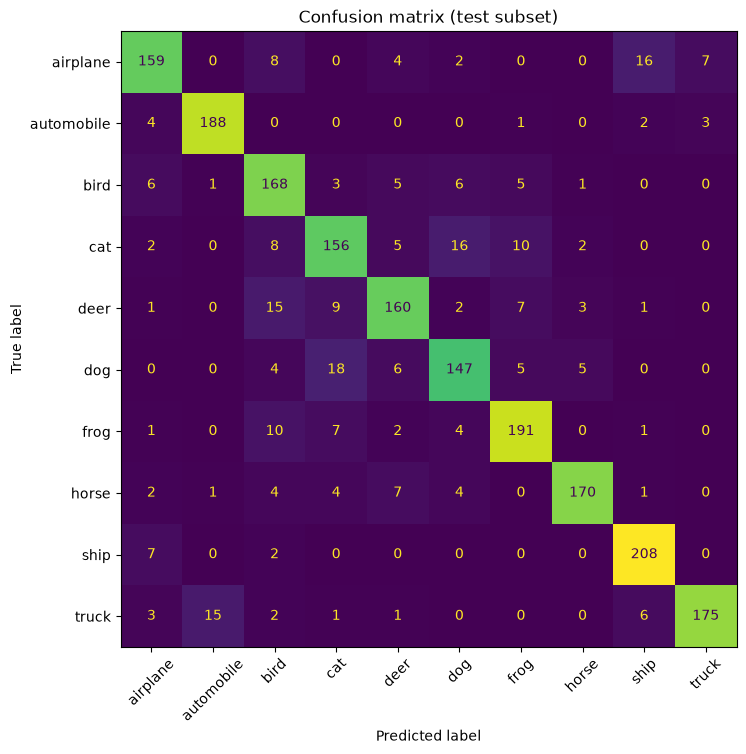

              precision    recall  f1-score   support

    airplane      0.859     0.811     0.835       196
  automobile      0.917     0.949     0.933       198
        bird      0.760     0.862     0.808       195
         cat      0.788     0.784     0.786       199
        deer      0.842     0.808     0.825       198
         dog      0.812     0.795     0.803       185
        frog      0.872     0.884     0.878       216
       horse      0.939     0.881     0.909       193
        ship      0.885     0.959     0.920       217
       truck      0.946     0.862     0.902       203

    accuracy                          0.861      2000
   macro avg      0.862     0.859     0.860      2000
weighted avg      0.863     0.861     0.861      2000



In [15]:
probs = model.predict(x_test_f, verbose=0)
y_pred = probs.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, xticks_rotation=45)
plt.title("Confusion matrix (test subset)"); plt.show()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

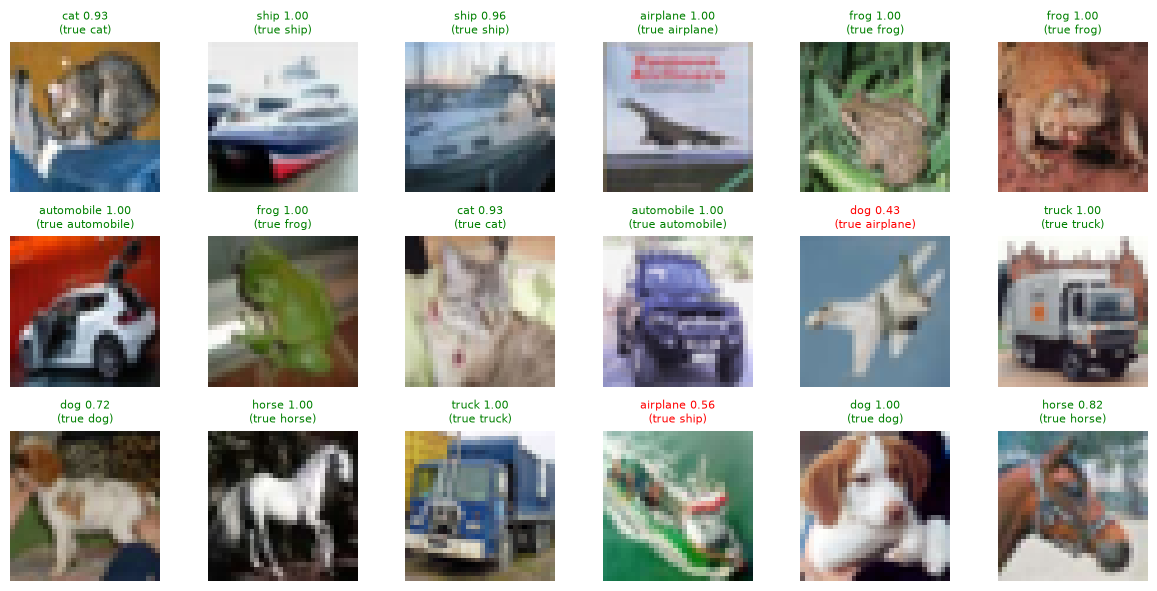

In [16]:
plt.figure(figsize=(12, 6))
for k in range(18):
    plt.subplot(3, 6, k + 1)
    plt.imshow(x_test[k])
    ok = y_pred[k] == y_test[k]
    plt.title(f"{CLASS_NAMES[y_pred[k]]} {probs[k].max():.2f}\n(true {CLASS_NAMES[y_test[k]]})",
              fontsize=8, color="green" if ok else "red")
    plt.axis("off")
plt.tight_layout(); plt.show()

## Hyperparameters to tune (Step e continued)

| Hyperparameter | Value used | Try |
|---|---|---|
| `N_TRAIN` | 10,000 | 25,000 or all 50,000 (slower, more accurate) |
| `HEAD_EPOCHS` | 5 | 8-10 |
| `FINE_TUNE_FROM` | 100 | 120 (fewer layers) or 60 (more layers) |
| fine-tune learning rate | 1e-5 | 1e-4 (faster, riskier) |
| Dropout | 0.3 | 0.2-0.5 |
| `IMG_SIZE` | 96 | 128 (better accuracy, needs the 128 weights file and more time) |

Compare this with Practical 3: a CNN trained from scratch on all 50,000 images reaches about 70-75%. Transfer learning reaches a similar or better level using only 10,000 images and a few epochs, because the features learned on ImageNet transfer to the new task.

## Conclusion

We loaded MobileNetV2 with ImageNet weights, froze its convolutional layers, added and trained a new classifier head, then unfroze the top layers and fine-tuned with a small learning rate. Transfer learning gives high accuracy with little data and short training time.